In [1]:
# First load some libraries, including History Matching
%load_ext autoreload
%autoreload 2

import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyDOE import lhs
from history_matching import HistoryMatching, HistoryMatchingCut, quick_read, Basis

sys.path.append("..") # Adds higher directory to python modules path.
from sir import SIR

/usr/lib/python3.7/site-packages/skcuda/cublas.py:283: UserWarning: creating CUBLAS context to get version number
  warnings.warn('creating CUBLAS context to get version number')


In [2]:
iteration = int(re.search(r'iter(\d+)', os.getcwd()).group(1)) # Index of the current iteration

In [3]:
# Observed data
observations = pd.DataFrame({
    'Times': [3, 15],
    'Prevalence': [15, 40],
    'Stdev': [4, 2.3],
})
print(observations)

# For this first iteration, we're going to make one "cut" using the first observation, but 
# you can separately do multiple "cuts" per iteration using several obervations (separately)
# We'll need a name for this cut and the desired results
cut_name = 'Prevalence_Meas' # No spaces or strange characters!

desired_result_idx = 1 # Second time point
desired_result = observations.iloc[desired_result_idx]['Prevalence']
desired_result_var = observations.iloc[desired_result_idx]['Stdev']**2

   Times  Prevalence  Stdev
0      3          15    4.0
1     15          40    2.3


In [4]:
# Here we define the parameter names and ranges
param_info = pd.DataFrame({
    'Name':['Beta', 'Gamma'],
    'Min':[1e-6, 1e-6],
    'Max':[0.01, 0.5]
}).set_index('Name')
params = param_info.index.values
n_params = param_info.shape[0] # We'll use this one place later
print(param_info)

            Min   Max
Name                 
Beta   0.000001  0.01
Gamma  0.000001  0.50


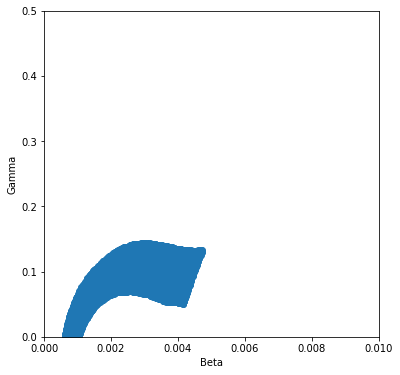

In [5]:
# Samples for the next iteration are saved to file, in this case it's "Candidates_for_iter1.csv"
# Just to see what they look like, we'll read that file and plot the samples
# Notice how the entire bottom right of the paramter space is empty?  Those points were rejected!

samples = pd.read_csv('Candidates_for_iter%d.csv'%(iteration+1))

f, ax = plt.subplots(figsize=(6,6))
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]])
ax.set_xlim([param_info['Min'][0], param_info['Max'][0]])
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]])
ax.set_xlabel(param_info.index.values[0])
ax.set_ylabel(param_info.index.values[1]);

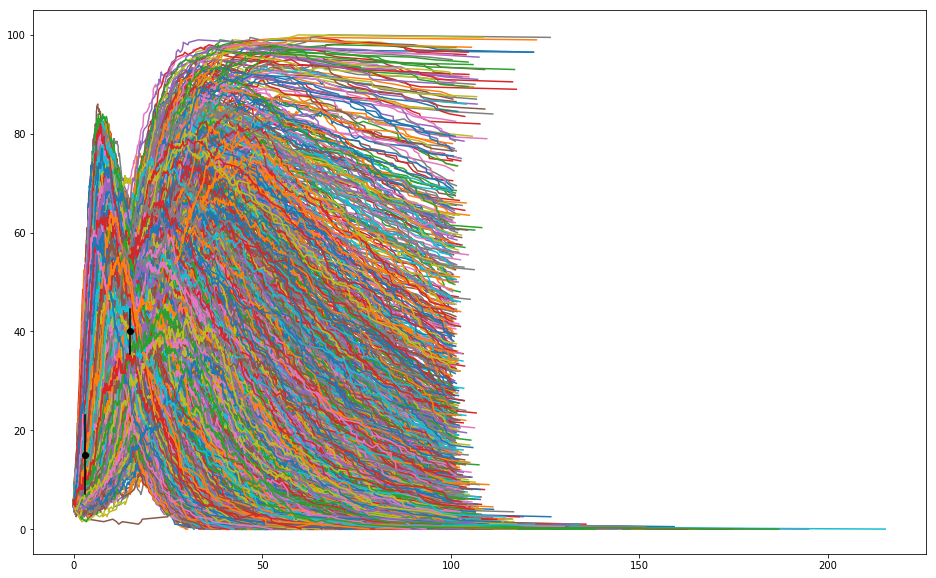

In [6]:
# Run the simulations specified by the samples and plot the results

f = plt.figure(figsize=(16,10))
sim_results = []

samples['Seed'] = np.random.randint(0, 1e6, samples.shape[0])

for idx, sample in samples.iterrows():
    z = SIR(beta=sample['Beta'], gamma=sample['Gamma'], seed=sample['Seed'])
    T,_,P = z.sim() # Run the simulation
    prevalence = [p[1] for p in P] # Analyze the simulation to get the prevalence
    
    # Because we used SSA, the time vector T does not contain the prevalence at the 
    # exact observation time, t_obs.  Let's find the first measurement after t_obs
    # Here I'm getting both observations, but we really only need one
    for i, t_obs in enumerate(observations['Times']):
        value = next((p[1] for t,p in zip(T,P) if t>t_obs), None)
        if not value:
            value = P[-1][1]
        sim_results.append([idx, i, t_obs, value])
    
    # Plot
    plt.plot(T,prevalence)

# Convert sim_results into a pandas DataFrame
sim_results = pd.DataFrame(sim_results, columns=['Sample_Id', 'ObsIdx', 'ObsTime', 'Prevalence'])

# Simulation results will ultimately need a 'Sample_Id' and 'Sim_Id'
# The Sample_Id corresponds to the index in the samples dataframe above
# You can do more than one replicate of each sample, in which case you'd
# end up wiht more than one Sim_Id per Sample_Id.  We're not doing that here,
# so we can basically set Sim_Id to anything.
sim_results['Sim_Id'] = sim_results['Sample_Id']
    
# Plot the observations over the realized trajectories
for i,obs in observations.iterrows():
    plt.plot(obs['Times'], obs['Prevalence'], 'ko')
    plt.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

In [7]:
def calc_goodness(sm):
    err2 = (sm['Prevalence'].values - observations['Prevalence'][sm['ObsIdx']].values)**2 / observations['Stdev'][sm['ObsIdx']].values**2
    return np.sqrt(np.sum(err2))


goodness = sim_results.groupby('Sample_Id').apply(calc_goodness)
print(goodness.head())

Sample_Id
0    0.993897
1    3.558202
2    4.516514
3    3.066494
4    6.407109
dtype: float64


Kept 501 parameter configurations


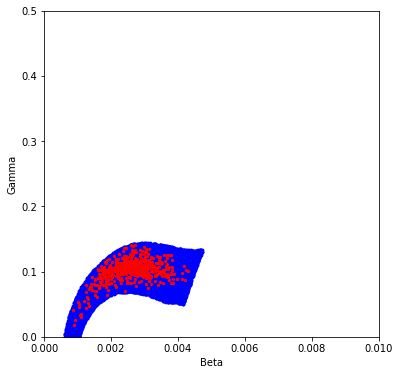

In [8]:
#keep_inds = goodness.sort_values(ascending=True).head(100).index
keep_inds = goodness[goodness < 1].index
print('Kept %d parameter configurations'%keep_inds.shape[0])

f, ax = plt.subplots(figsize=(6,6))
ax.scatter(x=samples[param_info.index.values[0]], y=samples[param_info.index.values[1]], color='b', s=8)
ax.scatter(x=samples.loc[keep_inds, param_info.index.values[0]], y=samples.loc[keep_inds, param_info.index.values[1]], color='r', s=5)

ax.set_xlim([param_info['Min'][0], param_info['Max'][0]])
ax.set_ylim([param_info['Min'][1], param_info['Max'][1]])
ax.set_xlabel(param_info.index.values[0])
ax.set_ylabel(param_info.index.values[1]);

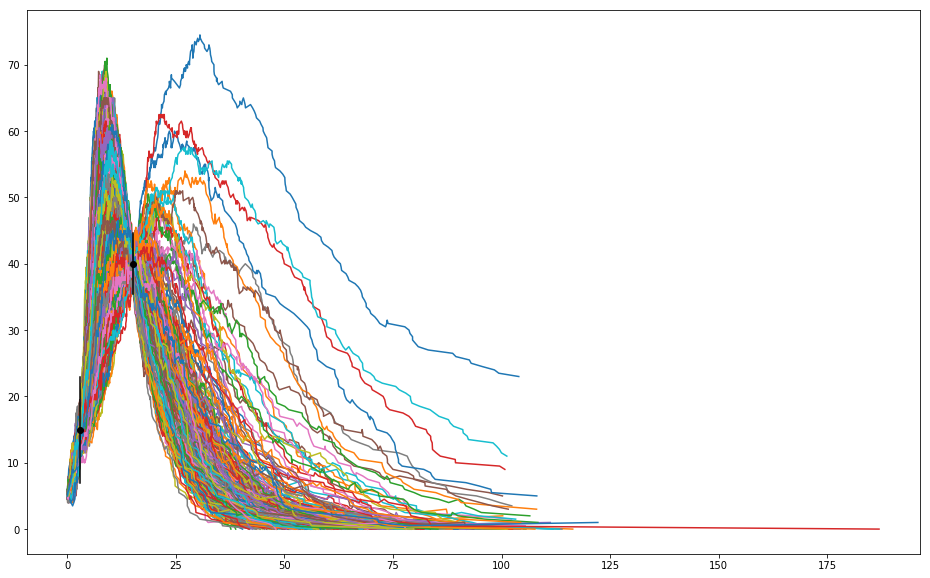

In [9]:
# Run the simulations specified by the samples and plot the results

f = plt.figure(figsize=(16,10))
sim_results = []

samples_keep = samples.iloc[keep_inds]

for idx, sample in samples_keep.iterrows():
    z = SIR(beta=sample['Beta'], gamma=sample['Gamma'], seed=sample['Seed'])
    T,_,P = z.sim() # Run the simulation
    prevalence = [p[1] for p in P] # Analyze the simulation to get the prevalence
    
    # Because we used SSA, the time vector T does not contain the prevalence at the 
    # exact observation time, t_obs.  Let's find the first measurement after t_obs
    # Here I'm getting both observations, but we really only need one
    for i, t_obs in enumerate(observations['Times']):
        value = next((p[1] for t,p in zip(T,P) if t>t_obs), None)
        if not value:
            value = P[-1][1]
        sim_results.append([idx, i, t_obs, value])
    
    # Plot
    plt.plot(T,prevalence)

# Convert sim_results into a pandas DataFrame
sim_results = pd.DataFrame(sim_results, columns=['Sample_Id', 'ObsIdx', 'ObsTime', 'Prevalence'])

# Simulation results will ultimately need a 'Sample_Id' and 'Sim_Id'
# The Sample_Id corresponds to the index in the samples dataframe above
# You can do more than one replicate of each sample, in which case you'd
# end up wiht more than one Sim_Id per Sample_Id.  We're not doing that here,
# so we can basically set Sim_Id to anything.
sim_results['Sim_Id'] = sim_results['Sample_Id']
    
# Plot the observations over the realized trajectories
for i,obs in observations.iterrows():
    plt.plot(obs['Times'], obs['Prevalence'], 'ko')
    plt.plot(
        [obs['Times'],obs['Times']], 
        [obs['Prevalence']-2*obs['Stdev'],obs['Prevalence']+2*obs['Stdev']],
        'k-')

ValueError: Unrecognized marker style 'm.'

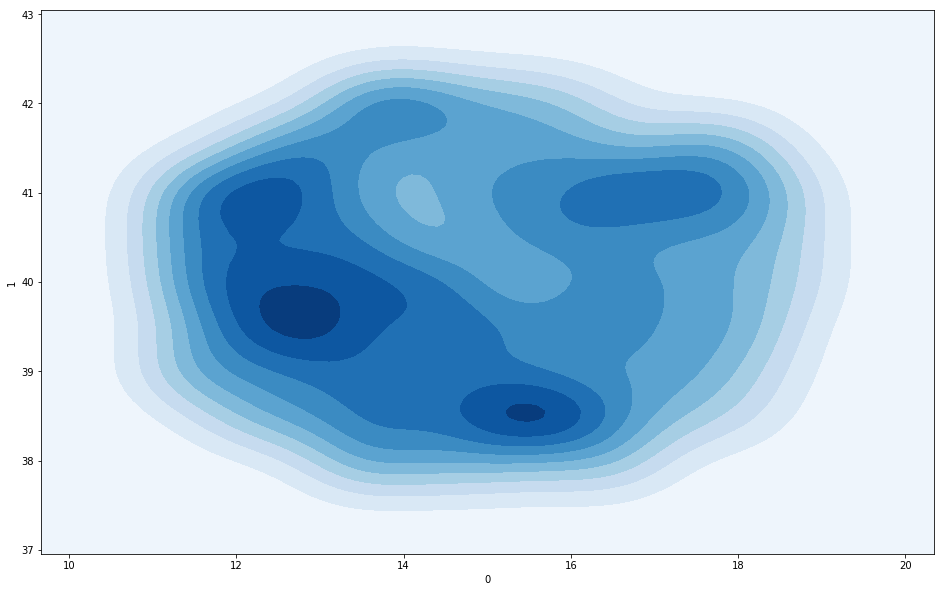

In [10]:
f, ax = plt.subplots(figsize=(16,10))

prev = sim_results.pivot('Sample_Id', 'ObsIdx', 'Prevalence')

sns.kdeplot(prev[0], prev[1], cmap="Blues", shade=True, shade_lowest=True, ax=ax)
ax.scatter(prev[0], prev[1], marker='m.', ms=3)
ax.plot(observations['Prevalence'][0], observations['Prevalence'][1], 'kx', ms=25, lw=3)
ax.plot(
    [observations['Prevalence'][0] - 2*observations['Stdev'][0], 
     observations['Prevalence'][0] + 2*observations['Stdev'][0]],
    [observations['Prevalence'][1], observations['Prevalence'][1]],
    'k-', lw=2)
ax.plot(
    [observations['Prevalence'][0], observations['Prevalence'][0]],
    [observations['Prevalence'][1] - 2*observations['Stdev'][1], 
     observations['Prevalence'][1] + 2*observations['Stdev'][1]],
    'k-', lw=2)
plt.show()